# Normal toy example using SBI

In [1]:
import torch
import numpy as np
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from sbi.utils.torchutils import BoxUniform


torch_device = "cpu"
torch.set_default_device(torch_device)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [40]:
prior_torch = BoxUniform(
    low=torch.tensor([0.0, 10.0], device=torch_device),
    high=torch.tensor([10.0, 1000.0], device=torch_device),
    device=torch_device
)

In [41]:
def simulator_torch_1(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s1 = torch.tensor([torch.mean(x), theta[1]], device=torch_device)
    return s1

In [42]:
def simulator_torch_2(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s2 = torch.tensor([torch.mean(x), torch.mean(x**2), theta[1]], device=torch_device)
    return s2

In [43]:
torch.manual_seed(1)
np.random.seed(1)
true_theta = torch.tensor([3.0, 100.0], device=torch_device)
x_o_2 = simulator_torch_2(true_theta)
x_o_1 = x_o_2[[0, 2]]
true_theta, x_o_1, x_o_2

(tensor([  3., 100.]),
 tensor([  2.7973, 100.0000]),
 tensor([  2.7973,   8.7726, 100.0000]))

In [44]:
def nrom_example_npe_c(
    simulation_budget, seed, prior, x_obs, simulator, num_posterior_samples=1000
):
    prior, num_parameters, prior_returns_numpy = process_prior(prior)
    simulator = process_simulator(simulator, prior, prior_returns_numpy)
    check_sbi_inputs(simulator, prior)

    inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)

    learning_rate = 0.0005  # default value

    torch.manual_seed(seed)
    np.random.seed(seed)

    theta, x = simulate_for_sbi(
        simulator=simulator, proposal=prior, num_simulations=simulation_budget
    )

    density_estimator = inference.append_simulations(theta, x).train(
        max_num_epochs=100, learning_rate=learning_rate
    )
    posterior = inference.build_posterior(density_estimator).set_default_x(x_obs)

    theta_trained = posterior.sample((num_posterior_samples,), x=x_obs)
    theta_trained = theta_trained.reshape((num_posterior_samples, 2))

    return theta_trained.cpu().numpy()

In [51]:
posterior_1 = nrom_example_npe_c(1000, 1, prior_torch, x_o_1, simulator_torch_1)


100%|██████████| 1000/1000 [00:00<00:00, 20819.85it/s]


 Training neural network. Epochs trained: 101


1096it [00:00, 29239.57it/s]            


In [52]:
posterior_1

array([[  2.8086398,  99.454475 ],
       [  2.5508676,  99.857414 ],
       [  2.7990155, 102.1755   ],
       ...,
       [  2.6985662, 101.03114  ],
       [  2.7677944, 101.89511  ],
       [  2.7258382,  98.06439  ]], shape=(1000, 2), dtype=float32)

In [53]:
posterior_2 = nrom_example_npe_c(1000, 1, prior_torch, x_o_2, simulator_torch_2)

100%|██████████| 1000/1000 [00:00<00:00, 12973.81it/s]


 Neural network successfully converged after 98 epochs.


1084it [00:00, 31028.00it/s]            


In [54]:
posterior_2

array([[  2.7607052,  97.45318  ],
       [  2.6215096,  91.847595 ],
       [  2.771125 , 101.1183   ],
       ...,
       [  2.7637007,  93.34392  ],
       [  2.7335222,  96.24638  ],
       [  2.812796 ,  99.0093   ]], shape=(1000, 2), dtype=float32)

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

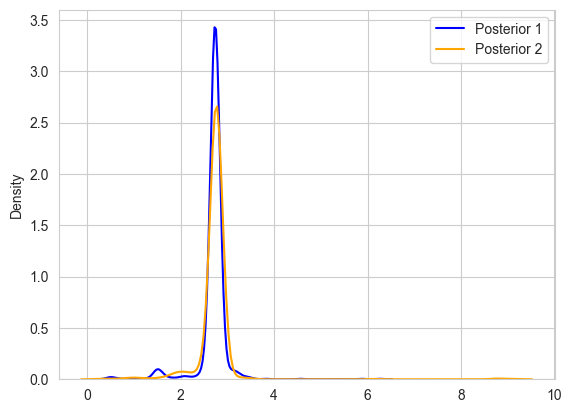

In [56]:
sns.set_style('whitegrid')
sns.kdeplot(posterior_1[:, 0], label='Posterior 1', color='blue')
sns.kdeplot(posterior_2[:, 0], label='Posterior 2', color='orange')
plt.legend()